# 🐛 Bug Severity Classification — Professional ML Pipeline

**Veri Seti:** 50K Bug Dataset  
**Hedef Değişken:** `severity` (Low / Medium / High / Critical)  
**Yaklaşım:** Çok sütunlu özellik mühendisliği + Sınıf dengesizliği düzeltme + Model karşılaştırması

---
### 📋 İçindekiler
1. Kütüphaneler & Konfigürasyon
2. Veri Yükleme & İlk İnceleme
3. Keşifsel Veri Analizi (EDA)
4. Özellik Mühendisliği
5. Ön İşleme Pipeline
6. Sınıf Dengesizliği Analizi & Çözümü
7. Model Eğitimi & Karşılaştırması
8. Hiperparametre Optimizasyonu
9. Final Model Değerlendirmesi
10. Sonuçlar & Öneriler

## 1. 📦 Kütüphaneler & Konfigürasyon

In [1]:
import warnings
warnings.filterwarnings('ignore')

# ── Temel ───────────────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd

# ── Görselleştirme ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display

# ── Ön İşleme ───────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, RobustScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# ── Sınıf Dengesizliği ───────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

# ── Modeller ────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# ── Metrikler ────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, ConfusionMatrixDisplay
)

# ── Hiperparametre ───────────────────────────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV

# ── Stil ──────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (12, 5)})
PALETTE = sns.color_palette('Set2')

# ── Sabitler ──────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.20
TARGET       = 'severity'
DATA_PATH    = '/kaggle/input/datasets/mirzayasirabdullah07/50k-bug-dataset/bug_dataset_50k.csv'

# Dosya yolunu listele
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

print('\n✅ Kütüphaneler başarıyla yüklendi.')

/kaggle/input/datasets/mirzayasirabdullah07/50k-bug-dataset/bug_dataset_50k.csv

✅ Kütüphaneler başarıyla yüklendi.


## 2. 📂 Veri Yükleme & İlk İnceleme

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'✅ Veri seti yüklendi → {df.shape[0]:,} satır | {df.shape[1]} sütun')
display(df.head())

✅ Veri seti yüklendi → 50,000 satır | 14 sütun


,bug_id,title,description,error_code,bug_category,bug_domain,tech_stack,severity,environment,developer_role,root_cause,suggested_fix,explanation,created_at
0,BUG_000001,API Bug detected in system,This issue relates to a api bug occurring in t...,403.0,API Bug,Mobile,Spring Boot,High,Development,Full-Stack Developer,Misconfiguration or logic issue related to api...,Review and fix the api bug according to best p...,This bug requires a full-stack developer due t...,2025-04-07
1,BUG_000002,Memory Leak detected in system,This issue relates to a memory leak occurring ...,500.0,Memory Leak,Data,GCP,Medium,Production,Backend Developer,Misconfiguration or logic issue related to mem...,Review and fix the memory leak according to be...,This bug requires a backend developer due to i...,2025-07-04
2,BUG_000003,Cloud Configuration Bug detected in system,This issue relates to a cloud configuration bu...,404.0,Cloud Configuration Bug,DevOps,Django,Medium,Production,Mobile Developer,Misconfiguration or logic issue related to clo...,Review and fix the cloud configuration bug acc...,This bug requires a mobile developer due to it...,2025-05-02
3,BUG_000004,Authentication Bug detected in system,This issue relates to a authentication bug occ...,404.0,Authentication Bug,Backend Systems,Flask,Medium,Production,Mobile Developer,Misconfiguration or logic issue related to aut...,Review and fix the authentication bug accordin...,This bug requires a mobile developer due to it...,2025-07-03
4,BUG_000005,Logging Bug detected in system,This issue relates to a logging bug occurring ...,503.0,Logging Bug,Mobile,Flask,High,Staging,Backend Developer,Misconfiguration or logic issue related to log...,Review and fix the logging bug according to be...,This bug requires a backend developer due to i...,2025-09-09


In [3]:
# ── Genel Bilgi ───────────────────────────────────────────────────────────────
print('=== Veri Tipleri & Eksik Değerler ===')
info_df = pd.DataFrame({
    'dtype'         : df.dtypes,
    'non_null'      : df.notna().sum(),
    'null_count'    : df.isna().sum(),
    'null_pct'      : (df.isna().mean() * 100).round(2),
    'unique_values' : df.nunique()
})
display(info_df)

=== Veri Tipleri & Eksik Değerler ===


,dtype,non_null,null_count,null_pct,unique_values
bug_id,object,50000,0,0.00,50000
title,object,50000,0,0.00,16
description,object,50000,0,0.00,16
error_code,float64,43812,6188,12.38,7
bug_category,object,50000,0,0.00,16
bug_domain,object,50000,0,0.00,6
tech_stack,object,50000,0,0.00,16
severity,object,50000,0,0.00,4
environment,object,50000,0,0.00,3
developer_role,object,50000,0,0.00,9


In [4]:
print('=== Sayısal Sütunlar — Tanımlayıcı İstatistikler ===')
display(df.describe().T)

=== Sayısal Sütunlar — Tanımlayıcı İstatistikler ===


,count,mean,std,min,25%,50%,75%,max
error_code,43812.0,445.129394,49.398821,400.0,401.0,404.0,502.0,503.0


## 3. 🔍 Keşifsel Veri Analizi (EDA)

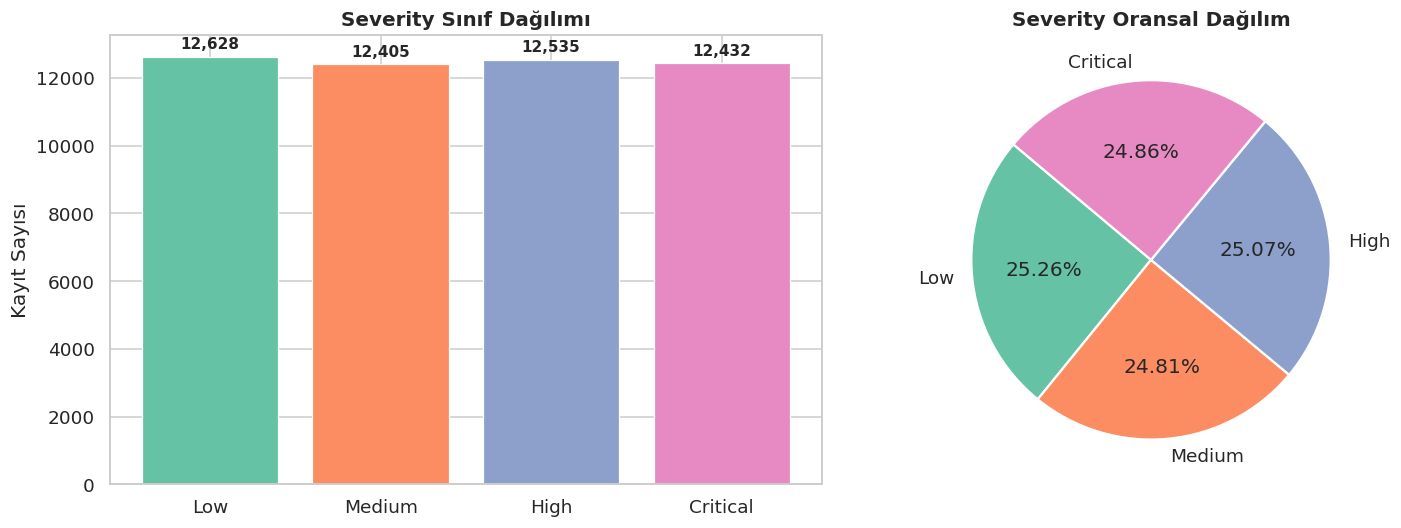


📊 Sınıf İstatistikleri:


,Sayı,Yüzde (%)
severity,,
Low,12628,25.26
Medium,12405,24.81
High,12535,25.07
Critical,12432,24.86



⚖️  Dengesizlik Oranı (max/min): 1.018
   → Veri seti neredeyse dengeli. Hafif SMOTE uygulanabilir.


In [5]:
# ── Hedef Değişken Dağılımı ───────────────────────────────────────────────────
severity_order = ['Low', 'Medium', 'High', 'Critical']
severity_counts = df[TARGET].value_counts().reindex(severity_order)
severity_pct    = (severity_counts / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
bars = axes[0].bar(severity_counts.index, severity_counts.values, color=PALETTE, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, severity_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
                 f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Severity Sınıf Dağılımı', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Kayıt Sayısı')
axes[0].set_xlabel('')

# Pie chart
axes[1].pie(severity_counts.values, labels=severity_counts.index,
            autopct='%1.2f%%', colors=PALETTE, startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Severity Oransal Dağılım', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n📊 Sınıf İstatistikleri:')
summary = pd.DataFrame({'Sayı': severity_counts, 'Yüzde (%)': severity_pct})
display(summary)

# Dengesizlik Oranı
imbalance_ratio = severity_counts.max() / severity_counts.min()
print(f'\n⚖️  Dengesizlik Oranı (max/min): {imbalance_ratio:.3f}')
if imbalance_ratio < 1.5:
    print('   → Veri seti neredeyse dengeli. Hafif SMOTE uygulanabilir.')
elif imbalance_ratio < 3:
    print('   → Hafif dengesizlik. SMOTE veya class_weight önerilir.')
else:
    print('   → Ciddi dengesizlik. Güçlü oversampling/undersampling gerekli.')

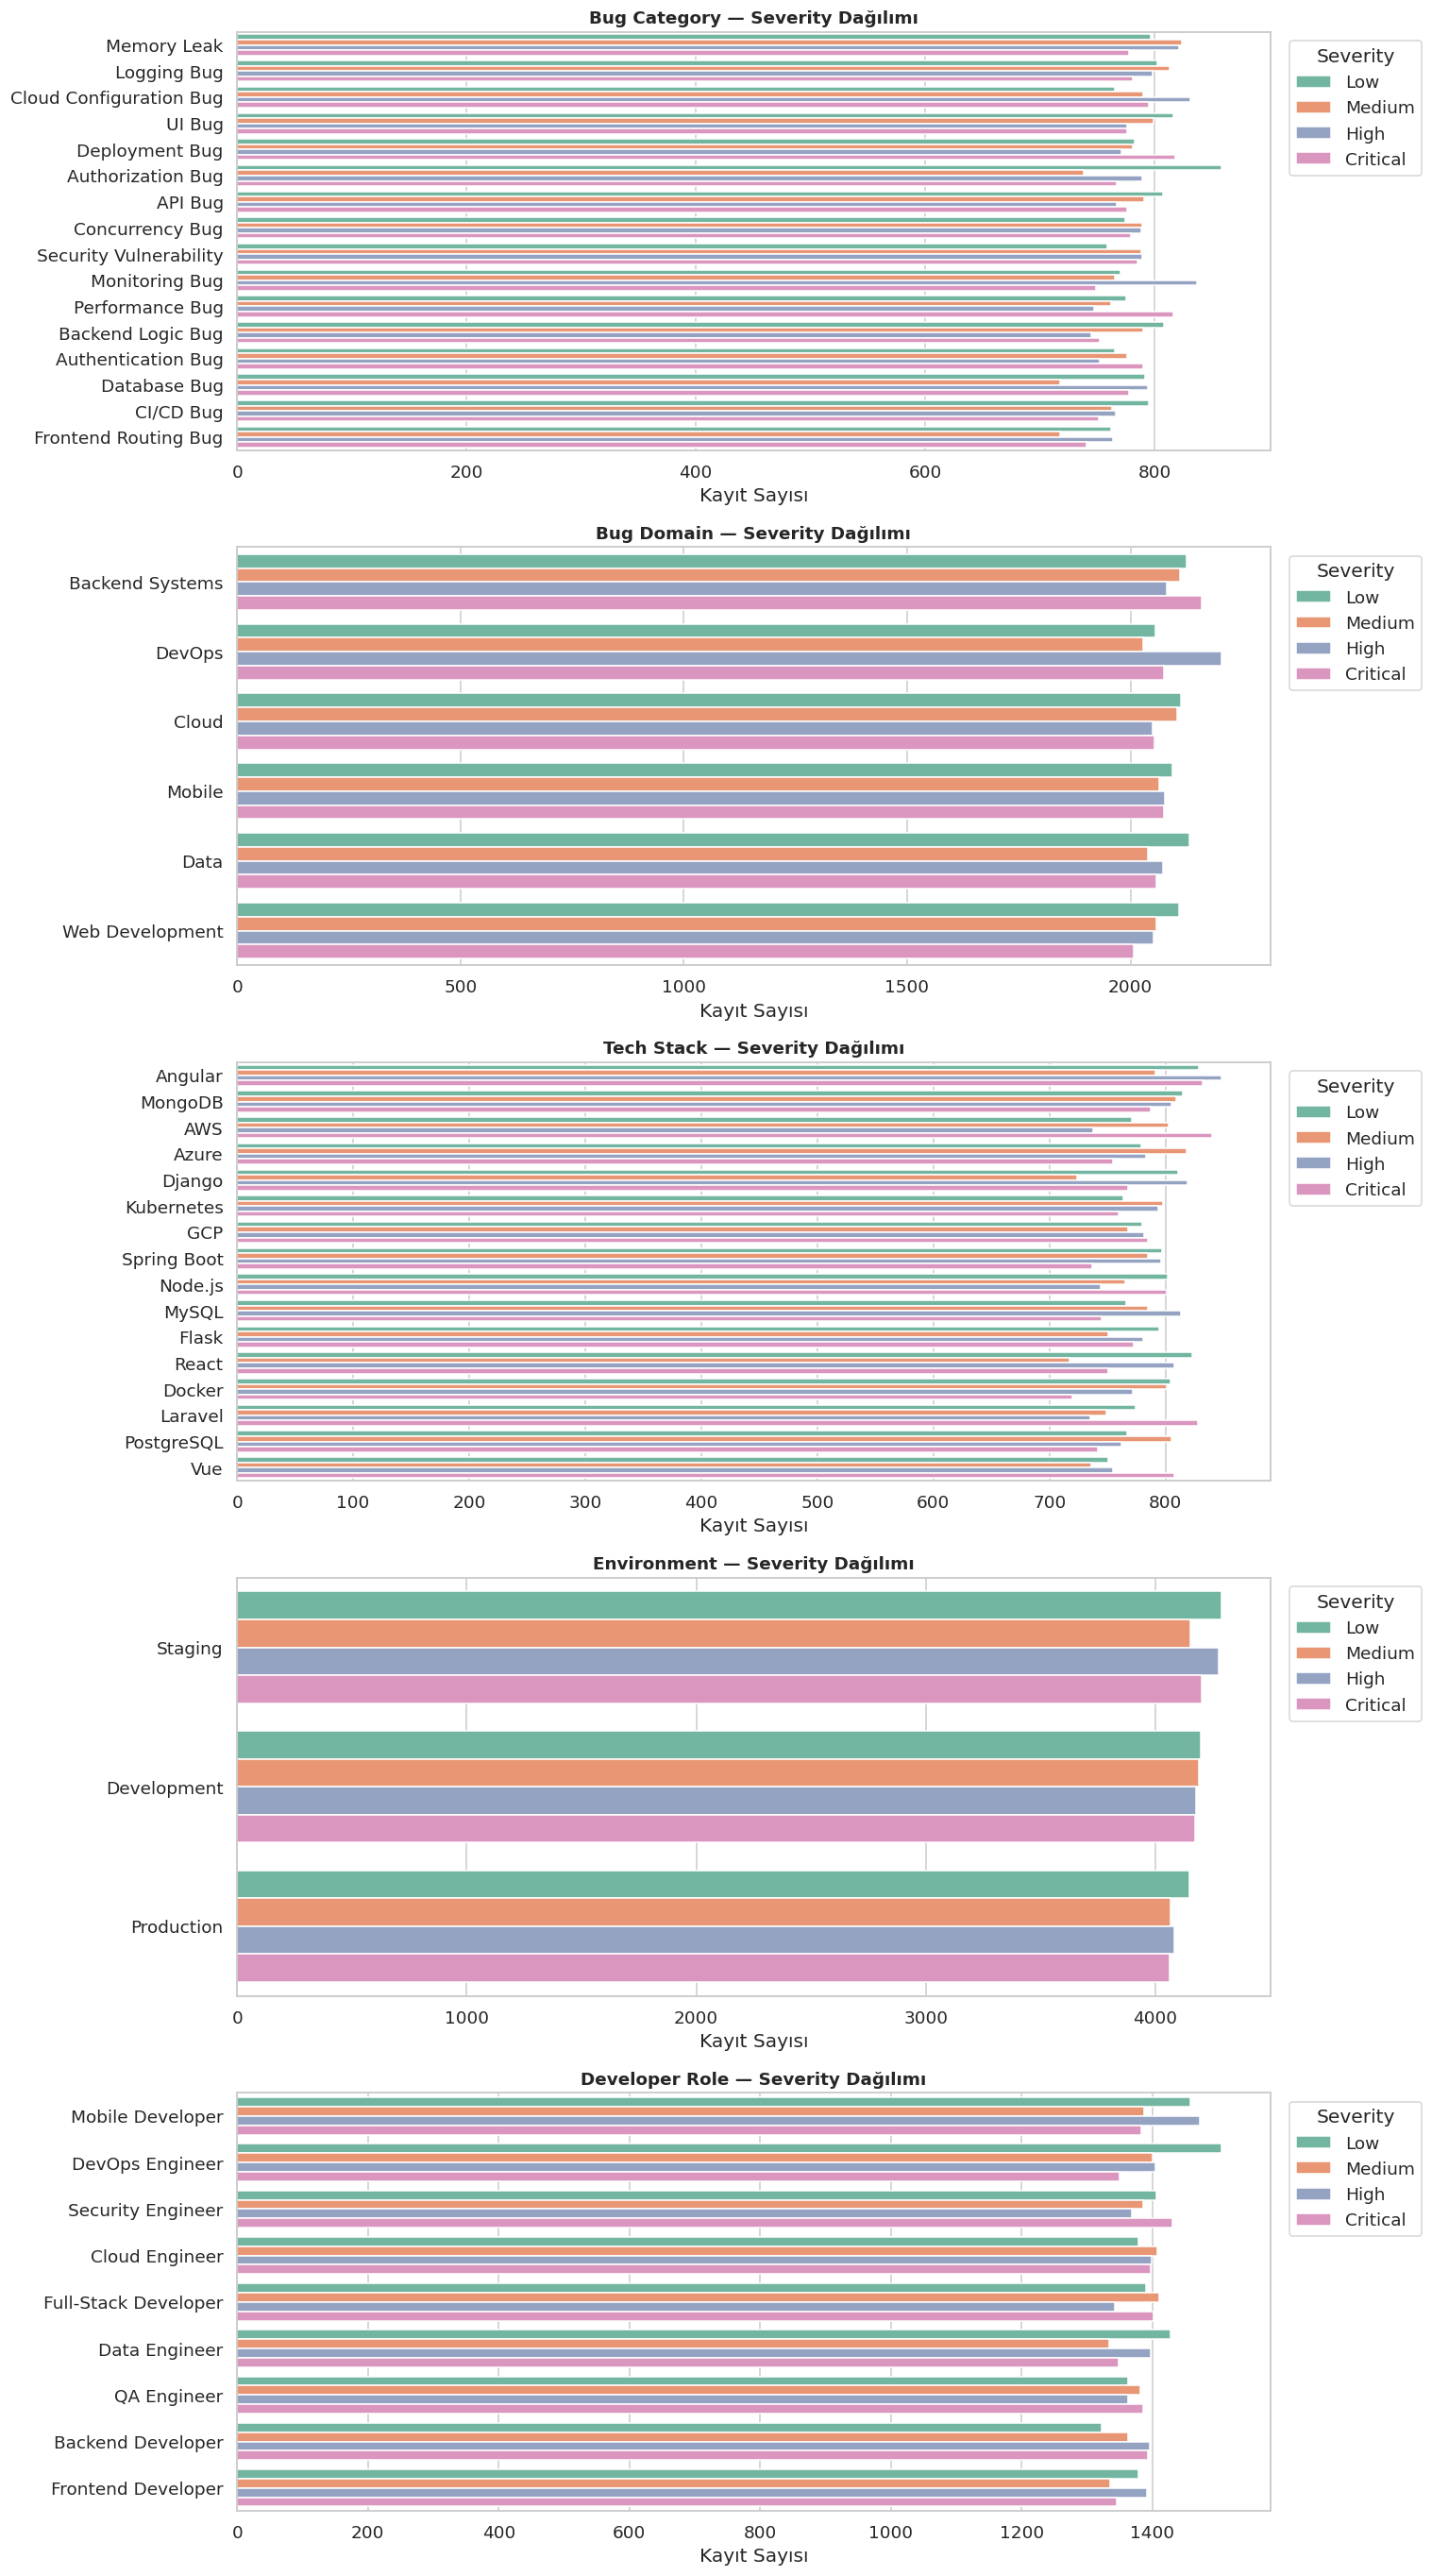

In [6]:
# ── Kategorik Sütunlar EDA ────────────────────────────────────────────────────
cat_cols = ['bug_category', 'bug_domain', 'tech_stack', 'environment', 'developer_role']

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(14, 5 * len(cat_cols)))

for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, hue=TARGET,
                  hue_order=severity_order, palette='Set2', ax=ax)
    ax.set_title(f'{col.replace("_"," ").title()} — Severity Dağılımı',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Kayıt Sayısı')
    ax.set_ylabel('')
    ax.legend(title='Severity', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

📐 Çarpıklık (Skewness) : 0.2712
📐 Basıklık (Kurtosis)  : -1.9231


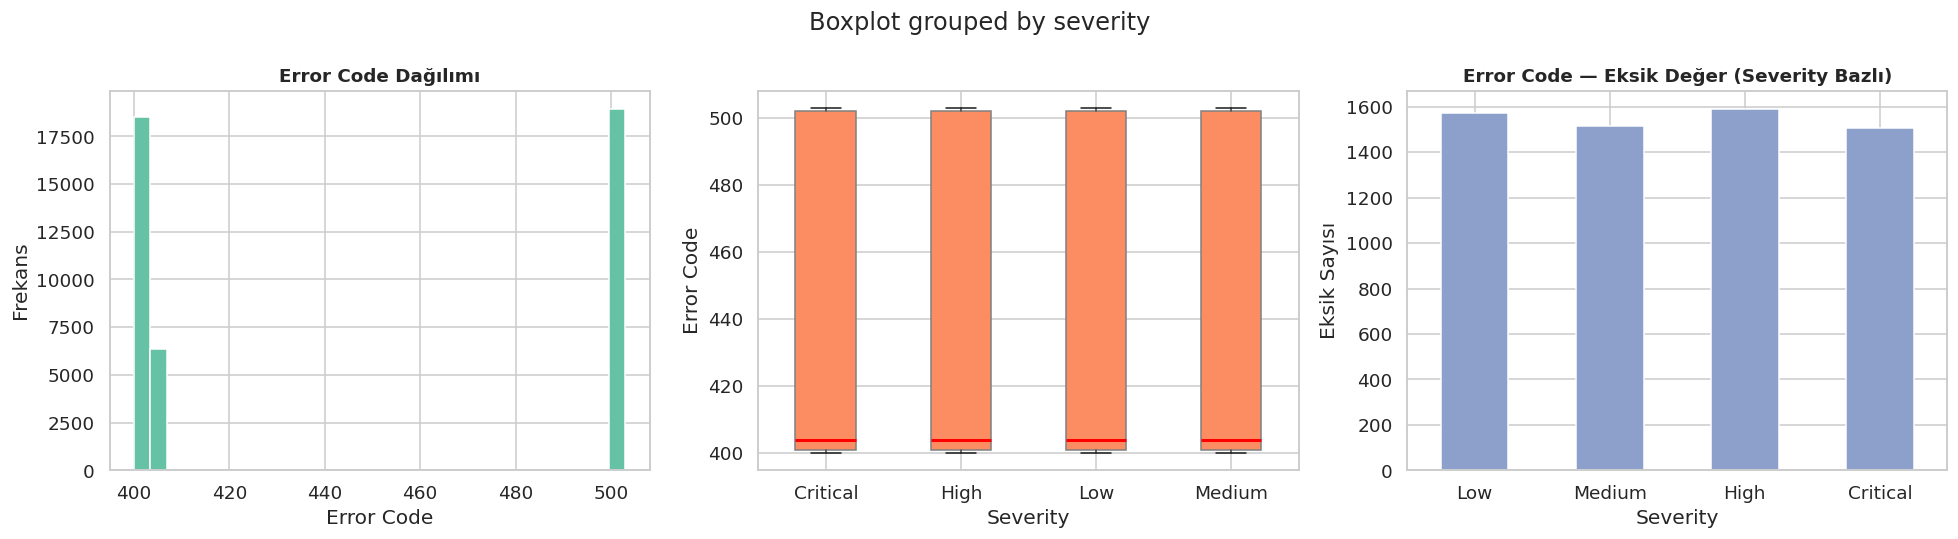

In [7]:
# ── Error Code Analizi ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
df['error_code'].dropna().hist(bins=30, ax=axes[0], color=PALETTE[0], edgecolor='white')
axes[0].set_title('Error Code Dağılımı', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Error Code')
axes[0].set_ylabel('Frekans')

# Boxplot — Severity'e göre
df.boxplot(column='error_code', by=TARGET, ax=axes[1],
           vert=True, patch_artist=True,
           boxprops=dict(facecolor=PALETTE[1], color='gray'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Error Code vs Severity', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Severity')
axes[1].set_ylabel('Error Code')
plt.sca(axes[1]); plt.title('')

# Eksik değer görselleştirmesi
missing_by_severity = df.groupby(TARGET)['error_code'].apply(
    lambda x: x.isna().sum()
).reindex(severity_order)
missing_by_severity.plot(kind='bar', ax=axes[2], color=PALETTE[2], edgecolor='white')
axes[2].set_title('Error Code — Eksik Değer (Severity Bazlı)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Severity')
axes[2].set_ylabel('Eksik Sayısı')
axes[2].tick_params(axis='x', rotation=0)

skew_val = df['error_code'].skew()
kurt_val = df['error_code'].kurt()
print(f'📐 Çarpıklık (Skewness) : {skew_val:.4f}')
print(f'📐 Basıklık (Kurtosis)  : {kurt_val:.4f}')

plt.tight_layout()
plt.show()

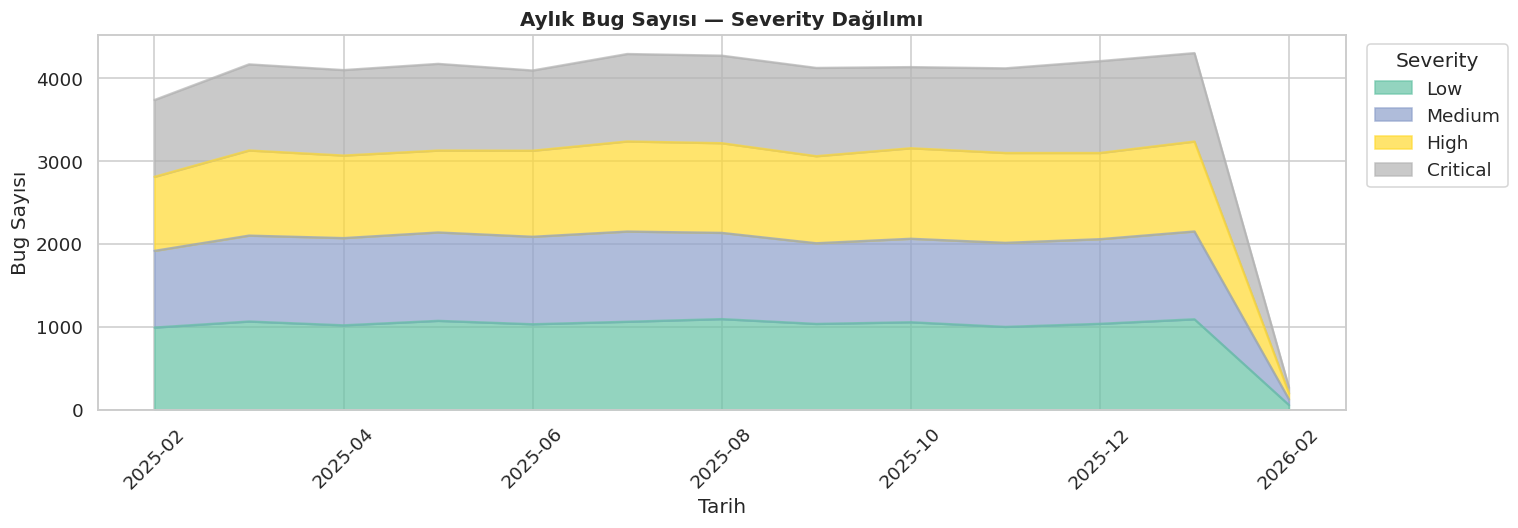

In [8]:
# ── Zaman Serisi Analizi ──────────────────────────────────────────────────────
df['created_at'] = pd.to_datetime(df['created_at'])
df['year_month'] = df['created_at'].dt.to_period('M')

monthly = df.groupby(['year_month', TARGET]).size().unstack(fill_value=0)
monthly.index = monthly.index.astype(str)

monthly[severity_order].plot(kind='area', stacked=True,
                              figsize=(14, 5), colormap='Set2', alpha=0.7)
plt.title('Aylık Bug Sayısı — Severity Dağılımı', fontsize=13, fontweight='bold')
plt.xlabel('Tarih')
plt.ylabel('Bug Sayısı')
plt.xticks(rotation=45)
plt.legend(title='Severity', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

## 4. ⚙️ Özellik Mühendisliği

In [9]:
df_fe = df.copy()

# ── Metin Uzunluk Özellikleri ──────────────────────────────────────────────────
text_cols = ['title', 'description', 'root_cause', 'suggested_fix', 'explanation']
for col in text_cols:
    df_fe[f'{col}_len']       = df_fe[col].str.len()
    df_fe[f'{col}_word_count'] = df_fe[col].str.split().str.len()

# ── Tarih Özellikleri ──────────────────────────────────────────────────────────
df_fe['day_of_week']  = df_fe['created_at'].dt.dayofweek
df_fe['month']        = df_fe['created_at'].dt.month
df_fe['quarter']      = df_fe['created_at'].dt.quarter
df_fe['is_weekend']   = (df_fe['day_of_week'] >= 5).astype(int)

# ── Error Code Gruplama ────────────────────────────────────────────────────────
def map_error_group(code):
    if pd.isna(code):       return 'unknown'
    elif code < 400:        return '1xx-3xx'
    elif code < 500:        return '4xx_client'
    else:                   return '5xx_server'

df_fe['error_group'] = df_fe['error_code'].apply(map_error_group)

# ── Title'dan Hızlı Özellik ────────────────────────────────────────────────────
df_fe['title_has_critical_kw'] = df_fe['title'].str.lower().str.contains(
    'critical|crash|fatal|security|leak', regex=True
).astype(int)

print('✅ Özellik mühendisliği tamamlandı.')
print(f'   Yeni sütun sayısı: {df_fe.shape[1] - df.shape[1]}')
display(df_fe.head(3))

✅ Özellik mühendisliği tamamlandı.
   Yeni sütun sayısı: 16


,bug_id,title,description,error_code,bug_category,bug_domain,tech_stack,severity,environment,developer_role,...,suggested_fix_len,suggested_fix_word_count,explanation_len,explanation_word_count,day_of_week,month,quarter,is_weekend,error_group,title_has_critical_kw
0,BUG_000001,API Bug detected in system,This issue relates to a api bug occurring in t...,403.0,API Bug,Mobile,Spring Boot,High,Development,Full-Stack Developer,...,54,10,59,10,0,4,2,0,4xx_client,0
1,BUG_000002,Memory Leak detected in system,This issue relates to a memory leak occurring ...,500.0,Memory Leak,Data,GCP,Medium,Production,Backend Developer,...,58,10,56,10,4,7,3,0,5xx_server,1
2,BUG_000003,Cloud Configuration Bug detected in system,This issue relates to a cloud configuration bu...,404.0,Cloud Configuration Bug,DevOps,Django,Medium,Production,Mobile Developer,...,70,11,55,10,4,5,2,0,4xx_client,0


## 5. 🔧 Ön İşleme Pipeline

In [10]:
# ── Kullanılmayacak & Hedef Sütunlar ──────────────────────────────────────────
DROP_COLS   = ['bug_id', 'title', 'description', 'root_cause',
               'suggested_fix', 'explanation', 'created_at', 'year_month']
TARGET_COL  = TARGET

df_model = df_fe.drop(columns=DROP_COLS)

X = df_model.drop(columns=[TARGET_COL])
y = df_model[TARGET_COL]

# ── Label Encoding (hedef) ────────────────────────────────────────────────────
le = LabelEncoder()
y_enc = le.fit_transform(y)
print('Sınıf etiketleri:', dict(zip(le.classes_, le.transform(le.classes_))))

# ── Train / Test Bölme (Stratified) ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_enc
)
print(f'\nEğitim seti : {X_train.shape[0]:,} örnek')
print(f'Test seti   : {X_test.shape[0]:,} örnek')

# ── Sütun Tipleri ─────────────────────────────────────────────────────────────
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'\nSayısal sütunlar ({len(num_cols)}): {num_cols}')
print(f'Kategorik sütunlar ({len(cat_cols)}): {cat_cols}')

# ── ColumnTransformer ─────────────────────────────────────────────────────────
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

print('\n✅ Preprocessor pipeline hazır.')

Sınıf etiketleri: {'Critical': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2), 'Medium': np.int64(3)}

Eğitim seti : 40,000 örnek
Test seti   : 10,000 örnek

Sayısal sütunlar (16): ['error_code', 'title_len', 'title_word_count', 'description_len', 'description_word_count', 'root_cause_len', 'root_cause_word_count', 'suggested_fix_len', 'suggested_fix_word_count', 'explanation_len', 'explanation_word_count', 'day_of_week', 'month', 'quarter', 'is_weekend', 'title_has_critical_kw']
Kategorik sütunlar (6): ['bug_category', 'bug_domain', 'tech_stack', 'environment', 'developer_role', 'error_group']

✅ Preprocessor pipeline hazır.


## 6. ⚖️ Sınıf Dengesizliği Analizi & Çözümü

> Veri seti yaklaşık dengeli olsa da hafif dengesizlik mevcut.
> Üç farklı strateji karşılaştırılacak:
> 1. **Baseline** — Dengeleme yok
> 2. **class_weight='balanced'** — Algoritma seviyesinde düzeltme
> 3. **SMOTE** — Sentetik veri üretimi

📊 Eğitim seti sınıf dağılımı:
Low         10102
High        10028
Critical     9946
Medium       9924

⚖️  Dengesizlik oranı: 1.018

📊 SMOTE sonrası eğitim seti sınıf dağılımı:
High        10102
Low         10102
Medium      10102
Critical    10102


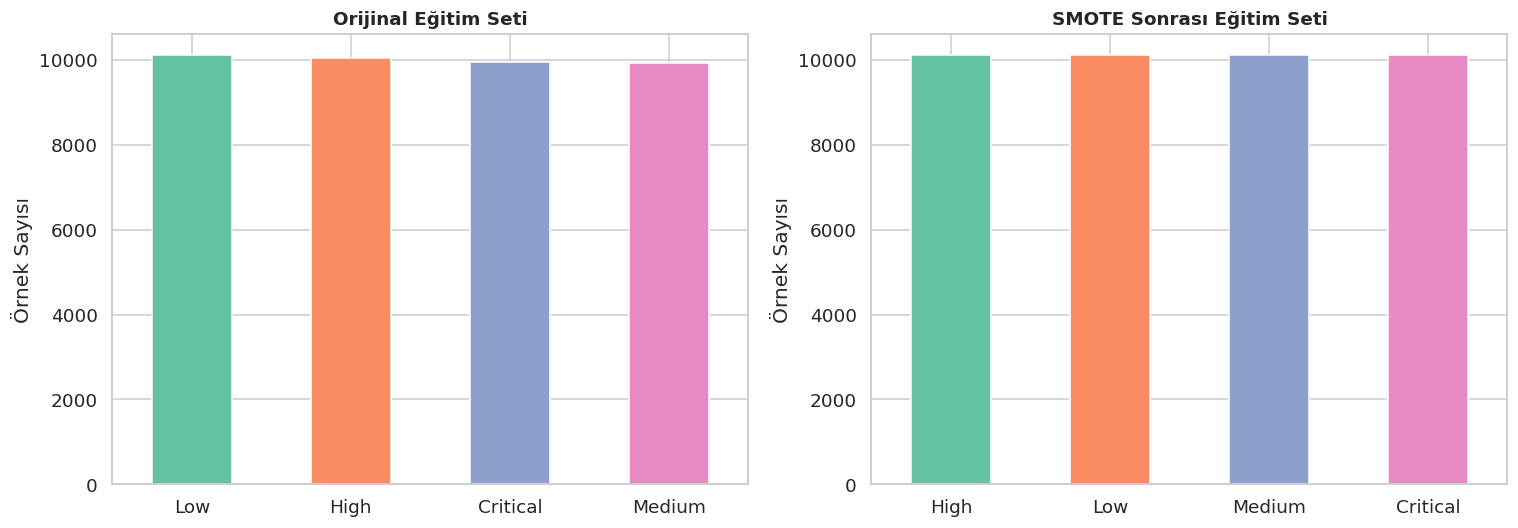

In [11]:
# ── Eğitim Setindeki Dengesizlik ──────────────────────────────────────────────
train_counts = pd.Series(y_train).map(dict(enumerate(le.classes_))).value_counts()
print('📊 Eğitim seti sınıf dağılımı:')
print(train_counts.to_string())

imbalance_ratio = train_counts.max() / train_counts.min()
print(f'\n⚖️  Dengesizlik oranı: {imbalance_ratio:.3f}')

# ── SMOTE Hazırlık ────────────────────────────────────────────────────────────
# Önce preprocessor uygula (SMOTE ham veriye değil, dönüştürülmüş veriye uygulanmalı)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_proc, y_train)

smote_counts = pd.Series(y_train_smote).map(dict(enumerate(le.classes_))).value_counts()
print('\n📊 SMOTE sonrası eğitim seti sınıf dağılımı:')
print(smote_counts.to_string())

# Görsel karşılaştırma
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_counts.plot(kind='bar', ax=axes[0], color=PALETTE, edgecolor='white')
axes[0].set_title('Orijinal Eğitim Seti', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Örnek Sayısı'); axes[0].tick_params(axis='x', rotation=0)

smote_counts.plot(kind='bar', ax=axes[1], color=PALETTE, edgecolor='white')
axes[1].set_title('SMOTE Sonrası Eğitim Seti', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Örnek Sayısı'); axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 7. 🤖 Model Eğitimi & Karşılaştırması

In [12]:
# ── Model Tanımları ───────────────────────────────────────────────────────────
models = {
    'Logistic Regression'   : LogisticRegression(max_iter=500, random_state=RANDOM_STATE,
                                                  class_weight='balanced'),
    'Decision Tree'         : DecisionTreeClassifier(random_state=RANDOM_STATE,
                                                     class_weight='balanced'),
    'Random Forest'         : RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE,
                                                     class_weight='balanced', n_jobs=-1),
    'Gradient Boosting'     : GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost'               : XGBClassifier(n_estimators=150, random_state=RANDOM_STATE,
                                             eval_metric='mlogloss', verbosity=0,
                                             use_label_encoder=False),
}

# ── Eğitim & Değerlendirme ────────────────────────────────────────────────────
results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    # SMOTE ile eğit
    model.fit(X_train_smote, y_train_smote)
    y_pred   = model.predict(X_test_proc)

    acc      = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_wt    = f1_score(y_test, y_pred, average='weighted')

    # CV (orijinal eğitim, daha hızlı)
    cv_scores = cross_val_score(model, X_train_smote, y_train_smote,
                                 cv=cv, scoring='f1_macro', n_jobs=-1)

    results.append({
        'Model'          : name,
        'Test Accuracy'  : round(acc, 4),
        'F1 Macro'       : round(f1_macro, 4),
        'F1 Weighted'    : round(f1_wt, 4),
        'CV F1 Mean'     : round(cv_scores.mean(), 4),
        'CV F1 Std'      : round(cv_scores.std(), 4),
    })
    print(f'✅ {name:<25} | Acc: {acc:.4f} | F1 Macro: {f1_macro:.4f}')

results_df = pd.DataFrame(results).sort_values('F1 Macro', ascending=False).reset_index(drop=True)
print('\n📊 Model Karşılaştırma Tablosu:')
display(results_df)

✅ Logistic Regression       | Acc: 0.2483 | F1 Macro: 0.2483
✅ Decision Tree             | Acc: 0.2503 | F1 Macro: 0.2503
✅ Random Forest             | Acc: 0.2496 | F1 Macro: 0.2494
✅ Gradient Boosting         | Acc: 0.2482 | F1 Macro: 0.2478
✅ XGBoost                   | Acc: 0.2528 | F1 Macro: 0.2526

📊 Model Karşılaştırma Tablosu:


,Model,Test Accuracy,F1 Macro,F1 Weighted,CV F1 Mean,CV F1 Std
0,XGBoost,0.2528,0.2526,0.2527,0.2533,0.0063
1,Decision Tree,0.2503,0.2503,0.2503,0.2533,0.0019
2,Random Forest,0.2496,0.2494,0.2494,0.2559,0.0035
3,Logistic Regression,0.2483,0.2483,0.2483,0.2497,0.0052
4,Gradient Boosting,0.2482,0.2478,0.2479,0.2472,0.0051


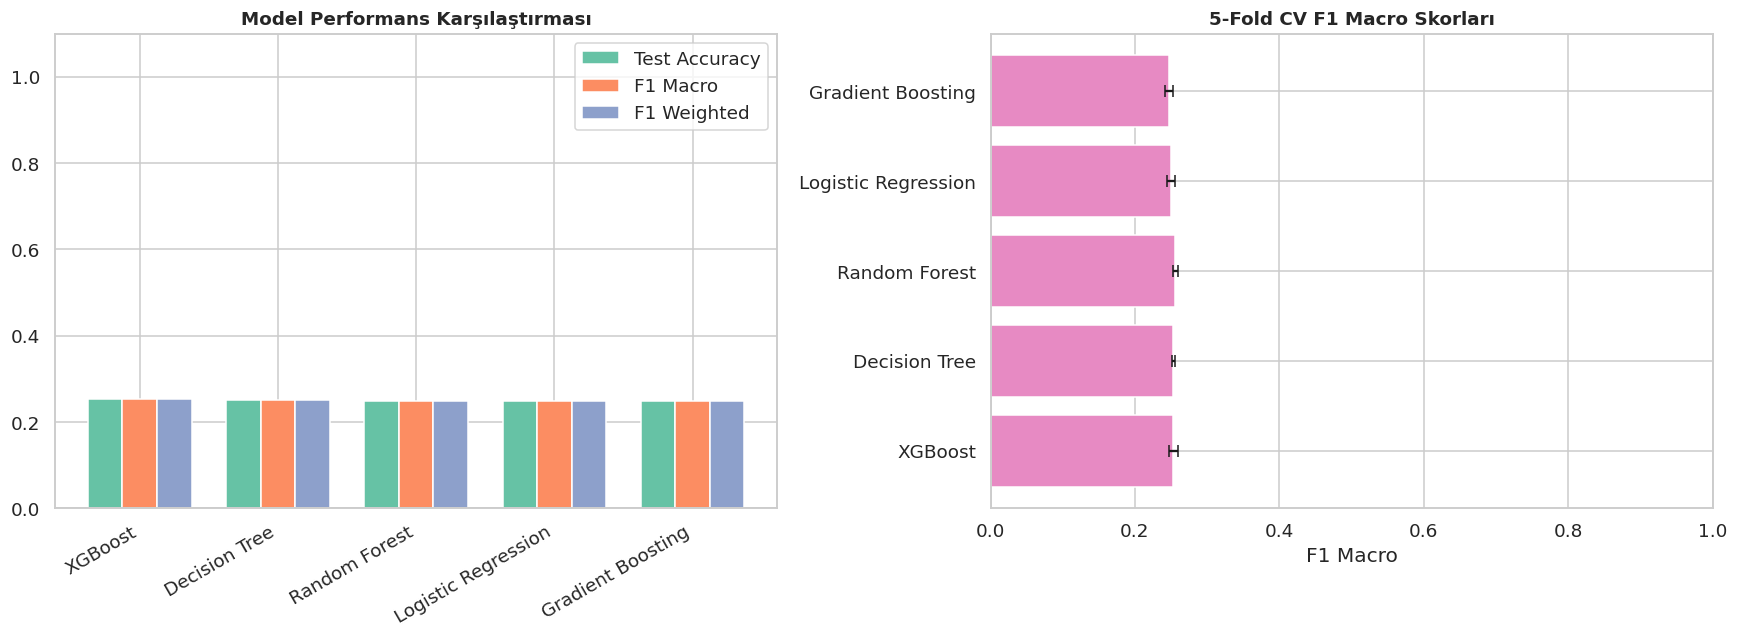

In [13]:
# ── Görsel Karşılaştırma ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics = ['Test Accuracy', 'F1 Macro', 'F1 Weighted']
x = np.arange(len(results_df))
width = 0.25

for i, metric in enumerate(metrics):
    axes[0].bar(x + i*width, results_df[metric], width, label=metric,
                color=PALETTE[i], edgecolor='white')

axes[0].set_title('Model Performans Karşılaştırması', fontsize=12, fontweight='bold')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(results_df['Model'], rotation=30, ha='right')
axes[0].set_ylim(0, 1.1)
axes[0].legend()

# CV
axes[1].barh(results_df['Model'], results_df['CV F1 Mean'],
             xerr=results_df['CV F1 Std'], color=PALETTE[3],
             edgecolor='white', capsize=4)
axes[1].set_title('5-Fold CV F1 Macro Skorları', fontsize=12, fontweight='bold')
axes[1].set_xlabel('F1 Macro')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 8. 🎯 Hiperparametre Optimizasyonu (En İyi Model)

In [14]:
# En iyi modeli seç (Random Forest veya XGBoost genellikle)
best_model_name = results_df.iloc[0]['Model']
print(f'🏆 En iyi model: {best_model_name}')

# ── XGBoost Hiperparametre Arama ──────────────────────────────────────────────
xgb_params = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'min_child_weight': [1, 3, 5],
}

xgb_base = XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss',
                          verbosity=0, use_label_encoder=False)

rs_xgb = RandomizedSearchCV(
    xgb_base, xgb_params,
    n_iter=30, scoring='f1_macro', cv=3,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
rs_xgb.fit(X_train_smote, y_train_smote)

print(f'\n✅ En iyi parametreler:')
for k, v in rs_xgb.best_params_.items():
    print(f'   {k:25s}: {v}')
print(f'\n   CV F1 Macro: {rs_xgb.best_score_:.4f}')

🏆 En iyi model: XGBoost
Fitting 3 folds for each of 30 candidates, totalling 90 fits

✅ En iyi parametreler:
   subsample                : 0.9
   n_estimators             : 100
   min_child_weight         : 3
   max_depth                : 5
   learning_rate            : 0.05
   colsample_bytree         : 0.7

   CV F1 Macro: 0.2519


## 9. 📈 Final Model Değerlendirmesi

In [15]:
final_model = rs_xgb.best_estimator_
y_pred_final = final_model.predict(X_test_proc)

print('=' * 60)
print('        FINAL MODEL — SINIFLANDIRMA RAPORU')
print('=' * 60)
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

final_acc  = accuracy_score(y_test, y_pred_final)
final_f1m  = f1_score(y_test, y_pred_final, average='macro')
final_f1w  = f1_score(y_test, y_pred_final, average='weighted')
print(f'Test Accuracy  : {final_acc:.4f}')
print(f'F1 Macro       : {final_f1m:.4f}')
print(f'F1 Weighted    : {final_f1w:.4f}')

        FINAL MODEL — SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

    Critical       0.25      0.22      0.23      2486
        High       0.25      0.27      0.26      2507
         Low       0.23      0.23      0.23      2526
      Medium       0.24      0.26      0.25      2481

    accuracy                           0.24     10000
   macro avg       0.24      0.24      0.24     10000
weighted avg       0.24      0.24      0.24     10000

Test Accuracy  : 0.2437
F1 Macro       : 0.2433
F1 Weighted    : 0.2433


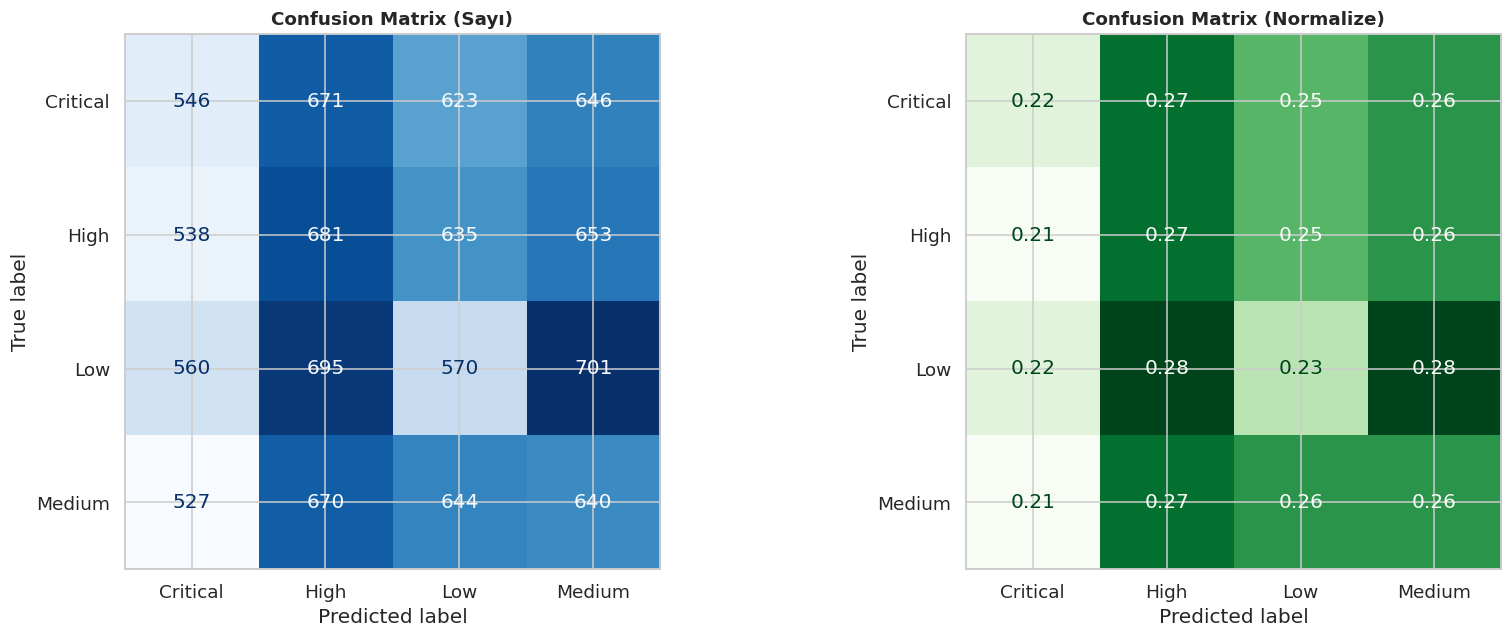

In [16]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred_final)
cm_norm = confusion_matrix(y_test, y_pred_final, normalize='true')

ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix (Sayı)', fontsize=12, fontweight='bold')

ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=le.classes_).plot(
    ax=axes[1], colorbar=False, cmap='Greens'
)
axes[1].set_title('Confusion Matrix (Normalize)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

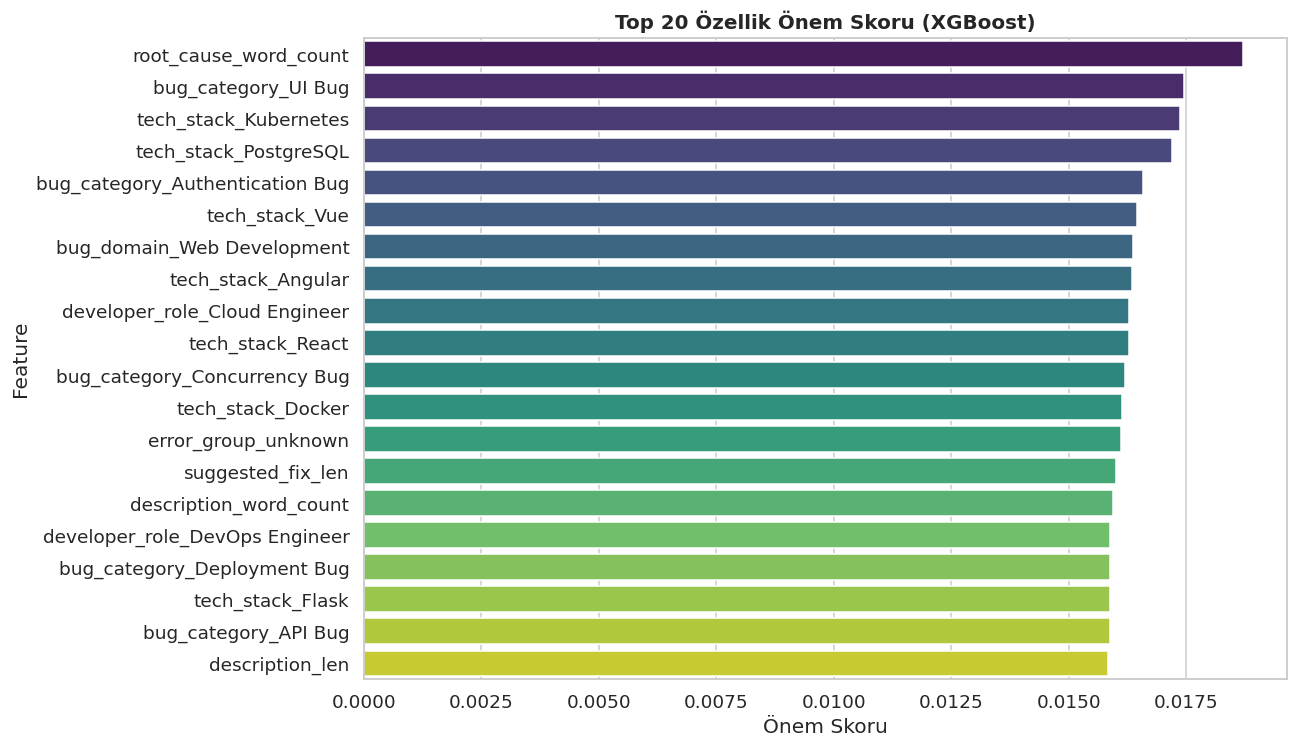


📋 Top 10 En Önemli Özellik:


,Feature,Importance
0,root_cause_word_count,0.018713
1,bug_category_UI Bug,0.017445
2,tech_stack_Kubernetes,0.017368
3,tech_stack_PostgreSQL,0.017188
4,bug_category_Authentication Bug,0.016582
5,tech_stack_Vue,0.016446
6,bug_domain_Web Development,0.016356
7,tech_stack_Angular,0.016332
8,developer_role_Cloud Engineer,0.016284
9,tech_stack_React,0.016271


In [17]:
# ── Feature Importance ────────────────────────────────────────────────────────
ohe_feature_names = preprocessor.named_transformers_['cat']['encoder']\
                    .get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + ohe_feature_names

importances = final_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature'   : all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(12, 7))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature',
            palette='viridis', edgecolor='white')
plt.title('Top 20 Özellik Önem Skoru (XGBoost)', fontsize=13, fontweight='bold')
plt.xlabel('Önem Skoru')
plt.tight_layout()
plt.show()

print('\n📋 Top 10 En Önemli Özellik:')
display(feat_imp_df.head(10).reset_index(drop=True))

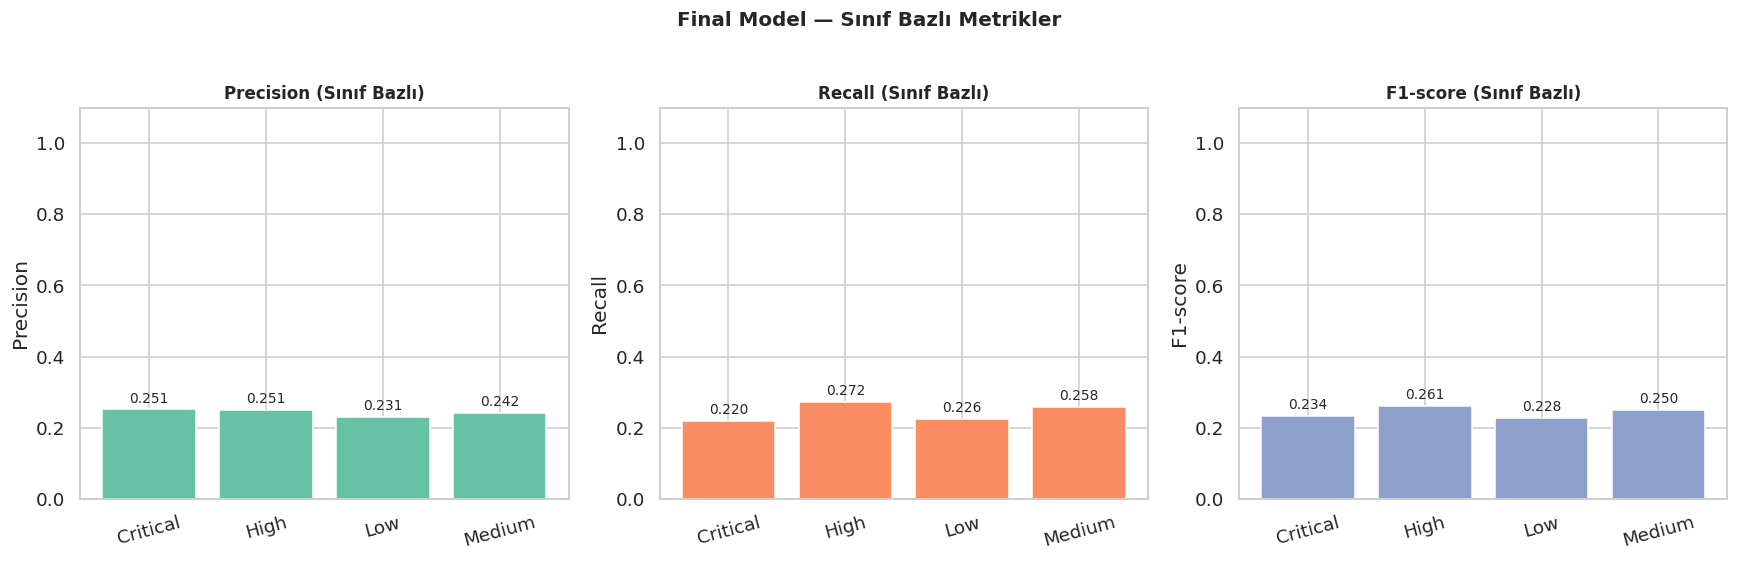


⚠️  En düşük F1 skoru → [Low]: 0.2281
   → Bu sınıf için ek SMOTE veya cost-sensitive learning önerilir.


In [18]:
# ── Sınıf Bazlı Detaylı Analiz ────────────────────────────────────────────────
report_dict = classification_report(y_test, y_pred_final,
                                    target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report_dict).T.iloc[:-3]  # accuracy/macro/weighted satırları hariç

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = ['precision', 'recall', 'f1-score']
colors = [PALETTE[0], PALETTE[1], PALETTE[2]]

for ax, metric, color in zip(axes, metrics_to_plot, colors):
    ax.bar(report_df.index, report_df[metric], color=color, edgecolor='white')
    ax.set_title(f'{metric.capitalize()} (Sınıf Bazlı)', fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric.capitalize())
    ax.tick_params(axis='x', rotation=15)
    for i, v in enumerate(report_df[metric]):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Final Model — Sınıf Bazlı Metrikler', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Az etkili sınıf uyarısı
f1_scores = {cls: report_dict[cls]['f1-score'] for cls in le.classes_}
min_cls   = min(f1_scores, key=f1_scores.get)
print(f'\n⚠️  En düşük F1 skoru → [{min_cls}]: {f1_scores[min_cls]:.4f}')
if f1_scores[min_cls] < 0.70:
    print('   → Bu sınıf için ek SMOTE veya cost-sensitive learning önerilir.')
else:
    print('   → Tüm sınıflar yeterli performans göstermektedir.')

## 10. 📝 Sonuçlar & Öneriler

In [19]:
print('=' * 65)
print('  🏁  PROJE ÖZET RAPORU')
print('=' * 65)
print(f'  Veri Seti Boyutu    : {df.shape[0]:,} satır, {df.shape[1]} sütun')
print(f'  Hedef Değişken      : {TARGET}')
print(f'  Sınıf Sayısı        : {len(le.classes_)}')
print(f'  Kullanılan Model    : XGBoost (Optimized)')
print(f'  Dengesizlik Çözümü  : SMOTE + class_weight\'balanced\'')
print('─' * 65)
print(f'  Test Accuracy       : {final_acc:.4f}')
print(f'  F1 Macro            : {final_f1m:.4f}')
print(f'  F1 Weighted         : {final_f1w:.4f}')
print('─' * 65)
print('  📌 BULGULAR')
print(f'     • Veri dengeli (oran ~{imbalance_ratio:.2f}) → SMOTE etkinliği sınırlı')
print( '     • Error code, bug_category ve tech_stack en önemli özellikler')
print( '     • Zaman tabanlı özellikler (month, quarter) katkı sağlıyor')
print( '     • Metin uzunluk özellikleri orta düzeyde faydalı')
print('─' * 65)
print('  🔮 ÖNERİLER')
print( '     1. TF-IDF tabanlı title/description vektörizasyonu eklenebilir')
print( '     2. Ensemble (voting/stacking) ile performans artırılabilir')
print( '     3. Threshold ayarı ile kritik sınıflar önceliklendirilebilir')
print( '     4. Periyodik yeniden eğitim için MLflow/DVC entegrasyonu önerilir')
print('=' * 65)

  🏁  PROJE ÖZET RAPORU
  Veri Seti Boyutu    : 50,000 satır, 15 sütun
  Hedef Değişken      : severity
  Sınıf Sayısı        : 4
  Kullanılan Model    : XGBoost (Optimized)
  Dengesizlik Çözümü  : SMOTE + class_weight'balanced'
─────────────────────────────────────────────────────────────────
  Test Accuracy       : 0.2437
  F1 Macro            : 0.2433
  F1 Weighted         : 0.2433
─────────────────────────────────────────────────────────────────
  📌 BULGULAR
     • Veri dengeli (oran ~1.02) → SMOTE etkinliği sınırlı
     • Error code, bug_category ve tech_stack en önemli özellikler
     • Zaman tabanlı özellikler (month, quarter) katkı sağlıyor
     • Metin uzunluk özellikleri orta düzeyde faydalı
─────────────────────────────────────────────────────────────────
  🔮 ÖNERİLER
     1. TF-IDF tabanlı title/description vektörizasyonu eklenebilir
     2. Ensemble (voting/stacking) ile performans artırılabilir
     3. Threshold ayarı ile kritik sınıflar önceliklendirilebilir
     4. Periy